<h1 align="center">
    THIS NOTEBOOK IS A PERSONAL REWORK OF THE Qiskit Machine Learning TUTORIAL
    <a href="https://qiskit-community.github.io/qiskit-machine-learning/tutorials/05_torch_connector.html">
        Torch Connector and Hybrid QNNs
    </a>
</h1>

The TorchConnector class allows for a natural integration of any NeuralNetwork from Qiskit Machine Learning into a PyTorch workflow. TorchConnector takes a NeuralNetwork and makes it available as a PyTorch Module. The resulting module can be seamlessly incorporated into PyTorch classical architectures and trained jointly without additional considerations, enabling the development and testing of novel hybrid quantum-classical machine learning architectures.

In [1]:
# Necessary imports

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.optim as optim
import torch.nn.functional as F

from torch import Tensor, cat, no_grad, manual_seed
from torch.optim import LBFGS
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.nn import (
    Module,
    Conv2d,
    Linear,
    Dropout2d,
    NLLLoss,
    MaxPool2d,
    Flatten,
    Sequential,
    ReLU,
    CrossEntropyLoss,
    MSELoss,
)

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import real_amplitudes, zz_feature_map
from qiskit_machine_learning.utils import algorithm_globals
from qiskit_machine_learning.neural_networks import SamplerQNN, EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector

from qiskit.primitives import StatevectorEstimator as Exact_estimator
from qiskit.primitives import StatevectorSampler as Exact_sampler

# Set seed for random generators
algorithm_globals.random_seed = 42

# Simple Classification

Here we use TorchConnector to train a Quantum NeuralNetwork to solve a binary classification task on a randomly generated dataset using PyTorch’s automatic differentiation engine.

**Structure**:
- Dataset preparation
- Model training
  - optimizer
  - loss function
  - PyTorch Neural Network module (_TorchConnector_ enters here)
    - initial weights
    - Quantum Neural Network (Estimator QNN or Sampler QNN)
        - primitive (Sampler or Estimator)
        - symbolic input and weight parameters
        - pass_manager
        - interpret function (for Sampler QNNs only)
        - output shape (for Sampler QNNs only)
        - input_gradients (whether gradients with respect to input data are computed by this NN in the backward method or not. Default: ```False```)
        - quantum circuit
          - feature map
          - ansatz

**Training steps:**
1. Set model into training mode

2. Reset gradients

3. Forward propagation

4. Loss calculation

5. Backward propagation

6. Parameter update

Training steps are repeated by encapsulating steps 2-5 into a _closure_ function to be passed as argument in step 6 (```optimizer.step(closure)```) for second-order optimizers (e.g., LBFGS), or by encapsulating steps 1-6 into a _for_ loop repeated an _epoch_ number of times for first-order optimizers (e.g., Adam)

-----------------------------------------------------------------------------------------------------------

**Notes:**

**Optimizer:**
when using TorchConnector, we get access to all of the optimizer algorithms defined in the [torch.optim] package. Some of the most famous algorithms used in popular machine learning architectures include Adam, SGD, or Adagrad. However, for this tutorial we will be using the L-BFGS algorithm (torch.optim.LBFGS), one of the most well know second-order optimization algorithms for numerical optimization.

- note from (https://pytorch.org/docs/stable/optim.html):
some optimization algorithms such as LBFGS need to reevaluate the function multiple times, so you have to pass in a _closure_ function as parameter that allows them to recompute your model.
The closure should clear the gradients, compute the loss, and return it.

**Loss Function:**
as for the loss function, we can also take advantage of PyTorch’s pre-defined modules from torch.nn, such as the Cross-Entropy or Mean Squared Error losses.

### Random dataset preparation

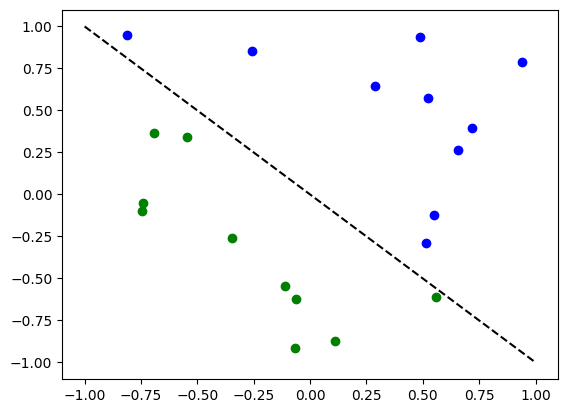

In [2]:
##################################################################################################
# Choose dataset dimension
num_inputs = 2   # number of features
num_samples = 20   # number of datapoints

##################################################################################################
# Generate random input coordinates (X) and binary labels (y)
X = 2 * algorithm_globals.random.random([num_samples, num_inputs]) - 1   # 20 x 2 random numbers in the range [-1, 1)
y01 = 1 * (np.sum(X, axis = 1) >= 0)   # binary label (0 or 1) which will be used for SamplerQNN example
y = 2 * y01 - 1  # binary label (-1 or 1) which will be used for EstimatorQNN example

##################################################################################################
# Convert from numpy ndarray to torch Tensors
X_ = Tensor(X)   # 20 x 2 Torch tensor
y01_ = Tensor(y01).reshape(len(y)).long()   # 20 x 1 Torch tensor. Long() converts data into 64 bit integers
y_ = Tensor(y).reshape(len(y), 1)   # 20 x 1 Torch tensor

##################################################################################################
# Plot dataset
for x, y_target in zip(X, y):
    if y_target == 1:
        plt.plot(x[0], x[1], "bo")
    else:
        plt.plot(x[0], x[1], "go")
plt.plot([-1, 1], [1, -1], "--", color="black")
plt.show()

### Classification with PyTorch and EstimatorQNN

**Note:**
in classical machine learning, the general rule of thumb is to apply a Cross-Entropy loss to classification tasks, and MSE loss to regression tasks. However, this recommendation is given under the assumption that the output of the classification network is a class probability value in the [0,1] range (usually this is achieved through a Softmax layer). Since the following example for EstimatorQNN does not include such layer, and we don’t apply any mapping to the output, the QNN’s output can take any value in the range [-1,1]. Therefore, here we use MSELoss for classification despite it not being the norm

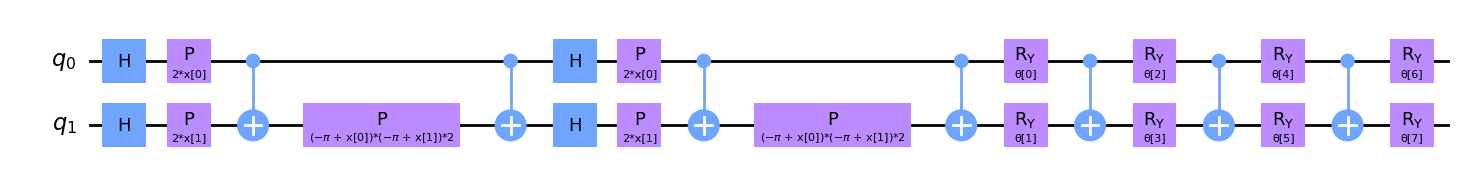

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Initial weights: [-0.01256962  0.06653564  0.04005302 -0.03752667  0.06645196  0.06095287
 -0.02250432 -0.04233438]

Loss:
25.454421997070312
22.745378494262695
20.256187438964844
19.70981788635254
19.172435760498047
18.766931533813477
18.967693328857422
18.00509262084961
17.247159957885742
16.695507049560547
16.003448486328125
15.713116645812988
15.233123779296875
15.05345344543457
15.117566108703613
14.981788635253906
14.756138801574707
14.607481956481934
15.090815544128418
15.178972244262695

Output: 0.09710326790809631 --> Prediction:1.0
Output: 0.07210814207792282 --> Prediction:1.0
Output: 0.27222564816474915 --> Prediction:1.0
Output: 0.19629627466201782 --> Prediction:1.0
Output: -0.20957720279693604 --> Prediction:-1.0
Output: 0.6082261204719543 --> Prediction:1.0
Output: 0.26393964886665344 --> Prediction:1.0
Output: -0.2145213931798935 --> Prediction:-1.0
Output: -0.5117729306221008 --> Prediction:-1.0
Output: 0.2923632264137268 --> Prediction:1.0
Output: -0.2622264623641968

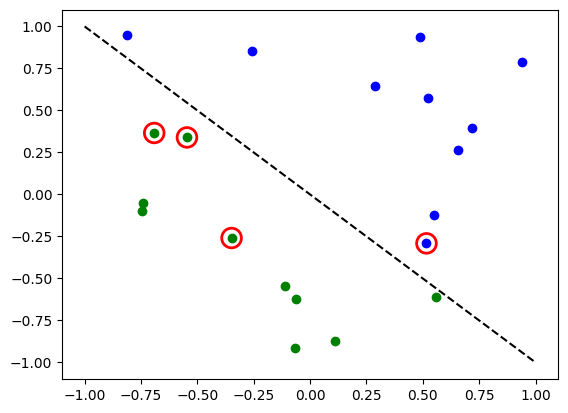

In [3]:
##################################################################################################
# Set up a circuit
feature_map = zz_feature_map(num_inputs)
ansatz = real_amplitudes(num_inputs)
qc = QuantumCircuit(num_inputs)
qc.compose(feature_map, inplace = True)
qc.compose(ansatz, inplace = True)
display(qc.draw(output = "mpl", style = "clifford"))

##################################################################################################
# Set up a primitive
estimator = Exact_estimator()

##################################################################################################
# Set up an EstimatorQNN
qnn1 = EstimatorQNN(
    circuit = qc,
    weight_params = ansatz.parameters,
    input_params = feature_map.parameters,
    estimator = estimator,
    pass_manager = None,
    input_gradients = False,
)

##################################################################################################
# Integrate the QNN into a PyTorch module
initial_weights = 0.1 * (2 * algorithm_globals.random.random(qnn1.num_weights) - 1)   # randoms in the range [-0.1, 0.1)
model1 = TorchConnector(qnn1, initial_weights = initial_weights)   # if we don't explicitly declare the initial weights they are chosen uniformly at random from [-1, 1]
print(f"Initial weights: {initial_weights}\n")

##################################################################################################
# Define optimizer and loss
optimizer = LBFGS(model1.parameters())
f_loss1 = MSELoss(reduction = "sum")

##################################################################################################
# Train the model: enter training mode, define closure function performing forward and backward passes, update parameters
model1.train()  # set model to training mode

print("Loss:")
def closure():
    optimizer.zero_grad()  # initialize/clear gradients
    outputs = model1(X_)   # forward pass: compute predicitons
    loss = f_loss1(outputs, y_)  # evaluate loss function
    loss.backward()  # backward pass: compute the gradient of the loss
    print(loss.item())  # print loss
    return loss
optimizer.step(closure)   # update parameters
print()

##################################################################################################
# Evaluate model and compute accuracy
model1.eval()   # enter evaluation mode

with torch.no_grad():
    y_predict = []
    for x in X:
        output = model1(Tensor(x))   # make predictions on the training dataset itself (there is no test daset in this example)
        y_predict.append(np.sign(output.detach().numpy())[0])
        print(f"Output: {output.detach()[0]} --> Prediction:{np.sign(output.detach().numpy())[0]}")
    
print()
print("Accuracy:", sum(y_predict == y) / len(y))

##################################################################################################
# Plot results
# red == wrongly classified
for x, y_target, y_p in zip(X, y, y_predict):
    if y_target == 1:
        plt.plot(x[0], x[1], "bo")
    else:
        plt.plot(x[0], x[1], "go")
    if y_target != y_p:
        plt.scatter(x[0], x[1], s = 200, facecolors = "none", edgecolors = "r", linewidths = 2)
plt.plot([-1, 1], [1, -1], "--", color="black")
plt.show()

### Classification with PyTorch and SamplerQNN

Linking a SamplerQNN to PyTorch requires a bit more attention than EstimatorQNN: without the correct setup, backpropagation is not possible.
In particular, we must make sure that we are returning a dense array of probabilities in the network’s forward pass (```sparse = False```). This parameter is set up to ```False``` by default, so we just have to make sure that it has not been changed.

**Note:** if we define a custom interpret function ( in the example: ```parity```), we must remember to explicitly provide the desired output shape ( in the example: 2)

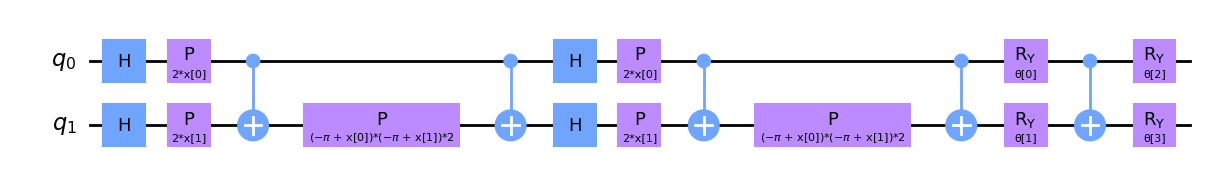

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Initial weights: [ 0.0364991  -0.0720495  -0.06001836 -0.09852755]

Loss:
0.6924787759780884
0.6885894536972046
0.6610277891159058
0.6557899713516235
0.6518258452415466
0.6423346996307373
0.6456717252731323
0.6305931806564331
0.6316249966621399
0.622078537940979
0.621979296207428
0.6185563802719116
0.6180229783058167
0.6163837909698486
0.618777871131897
0.621674656867981
0.6296391487121582
0.6230562329292297
0.6155379414558411
0.613464891910553

Output: [0.427734375, 0.572265625] --> Prediction:1
Output: [0.40625, 0.59375] --> Prediction:1
Output: [0.39453125, 0.60546875] --> Prediction:1
Output: [0.357421875, 0.642578125] --> Prediction:1
Output: [0.5107421875, 0.4892578125] --> Prediction:0
Output: [0.142578125, 0.857421875] --> Prediction:1
Output: [0.3525390625, 0.6474609375] --> Prediction:1
Output: [0.603515625, 0.396484375] --> Prediction:0
Output: [0.8076171875, 0.1923828125] --> Prediction:0
Output: [0.3701171875, 0.6298828125] --> Prediction:1
Output: [0.640625, 0.359375] -->

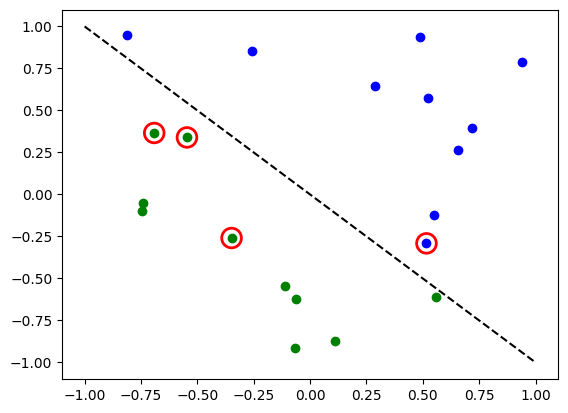

In [4]:
##################################################################################################
# Set up a circuit
feature_map = zz_feature_map(num_inputs)
ansatz = real_amplitudes(num_inputs,  entanglement = "linear", reps = 1)
qc = QuantumCircuit(num_inputs)
qc.compose(feature_map, inplace = True)
qc.compose(ansatz, inplace = True)
display(qc.draw(output = "mpl", style = "clifford"))

##################################################################################################
# Set up a primitive
sampler = Exact_sampler()

##################################################################################################
# Set up a SamplerQNN with an interpret function
parity = lambda x: "{:b}".format(x).count("1") % 2  # optional interpret function
output_shape = 2  # parity = 0, 1

qnn2 = SamplerQNN(
    circuit = qc,
    weight_params = ansatz.parameters,
    input_params = feature_map.parameters,
    interpret = parity,
    output_shape = output_shape,
    sampler = sampler,
    pass_manager = None,
    input_gradients = False,
)

##################################################################################################
# Integrate the QNN into a PyTorch module
initial_weights = 0.1 * (2 * algorithm_globals.random.random(qnn2.num_weights) - 1)   # randoms in the range [-0.1, 0.1)
model2 = TorchConnector(qnn2, initial_weights = initial_weights)   # if we don't explicitly declare the initial weights they are chosen uniformly at random from [-1, 1]
print(f"Initial weights: {initial_weights}\n")

##################################################################################################
# Define optimizer and loss
optimizer = LBFGS(model2.parameters())
f_loss2 = CrossEntropyLoss()  # Our output will be in the [0,1] range

##################################################################################################
# Train the model: enter training mode, define closure function performing forward and backward passes, update parameters
model2.train()  # set model to training mode

print("Loss:")
def closure():
    optimizer.zero_grad(set_to_none = True)  # initialize/clear gradients
    outputs = model2(X_)   # forward pass: compute predicitons
    loss = f_loss2(outputs, y01_)  # evaluate loss function
    loss.backward()  # backward pass: compute the gradient of the loss
    print(loss.item())  # print loss
    return loss
optimizer.step(closure)   # update parameters
print()

##################################################################################################
# Evaluate model and compute accuracy
model2.eval()   # enter evaluation mode

with torch.no_grad():
    y_predict = []
    for x in X:
        output = model2(Tensor(x))   # make predictions on the training dataset itself (there is no test daset in this example)
        y_predict.append(np.argmax(output.detach().numpy()))
        print(f"Output: {output.detach().tolist()} --> Prediction:{np.argmax(output.detach().numpy())}")
        
print()
print("Accuracy:", sum(y_predict == y01) / len(y01))

##################################################################################################
# Plot results
# red == wrongly classified
for x, y_target, y_ in zip(X, y01, y_predict):
    if y_target == 1:
        plt.plot(x[0], x[1], "bo")
    else:
        plt.plot(x[0], x[1], "go")
    if y_target != y_:
        plt.scatter(x[0], x[1], s = 200, facecolors="none", edgecolors="r", linewidths=2)
plt.plot([-1, 1], [1, -1], "--", color="black")
plt.show()

# Simple Regression

Here we use TorchConnector to train a Quantum NeuralNetwork to solve a regression task on a randomly generated dataset using PyTorch’s automatic differentiation engine.

**Structure**:
- Dataset preparation
- Model training
  - optimizer
  - loss function
  - PyTorch Neural Network module (_TorchConnector_ enters here)
    - initial weights
    - Quantum Neural Network (Estimator QNN)
        - primitive (Estimator)
        - symbolic input and weight parameters
        - pass_manager
        - input_gradients (whether gradients with respect to input data are computed by this NN in the backward method or not. Default: ```False```)
        - quantum circuit
          - feature map
          - ansatz

**Training steps:**
1. Set model into training mode

2. Reset gradients

3. Forward propagation

4. Loss calculation

5. Backward propagation

6. Parameter update

Training steps are repeated by encapsulating steps 2-5 into a _closure_ function to be passed as argument in step 6 (```optimizer.step(closure)```) for second-order optimizers (e.g., LBFGS), or by encapsulating steps 1-6 into a _for_ loop repeated an _epoch_ number of times for first-order optimizers (e.g., Adam)

-----------------------------------------------------------------------------------------------------------

**Notes:**

**Optimizer:**
when using TorchConnector, we get access to all of the optimizer algorithms defined in the [torch.optim] package. Some of the most famous algorithms used in popular machine learning architectures include Adam, SGD, or Adagrad. However, for this tutorial we will be using the L-BFGS algorithm (torch.optim.LBFGS), one of the most well know second-order optimization algorithms for numerical optimization.

- note from (https://pytorch.org/docs/stable/optim.html):
some optimization algorithms such as LBFGS need to reevaluate the function multiple times, so you have to pass in a _closure_ function as parameter that allows them to recompute your model.
The closure should clear the gradients, compute the loss, and return it.

**Loss Function:**
as for the loss function, we can also take advantage of PyTorch’s pre-defined modules from torch.nn, such as the Cross-Entropy or Mean Squared Error losses.

### Random dataset preparation

We generate a dataset following a sin function

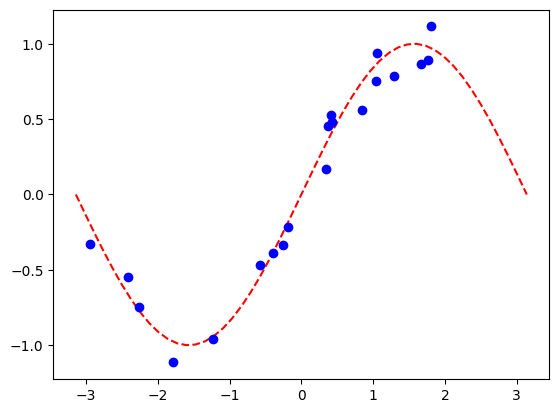

In [5]:
# Generate random dataset
num_samples = 20

eps = 0.2
lb, ub = -np.pi, np.pi
f = lambda x: np.sin(x)

X = (ub - lb) * algorithm_globals.random.random([num_samples, 1]) + lb   # 20 x 1 dataset: 1 feature!
y = f(X) + eps * (2 * algorithm_globals.random.random([num_samples, 1]) - 1)
plt.plot(np.linspace(lb, ub), f(np.linspace(lb, ub)), "r--")
plt.plot(X, y, "bo")
plt.show()

### Regression with PyTorch and EstimatorQNN

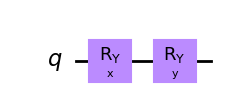

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Initial weights: [-0.01076874]

Loss:
15.141148567199707
2.840747594833374
6.762037754058838
0.4019446074962616
0.26143378019332886
0.26264673471450806
0.233221173286438
0.28626391291618347
0.25074630975723267
0.24628236889839172
0.25457149744033813
0.2276354730129242
0.2577882409095764
0.23340311646461487
0.2388676553964615
0.23919957876205444
0.2675033509731293
0.24364586174488068
0.2634309232234955
0.23880530893802643



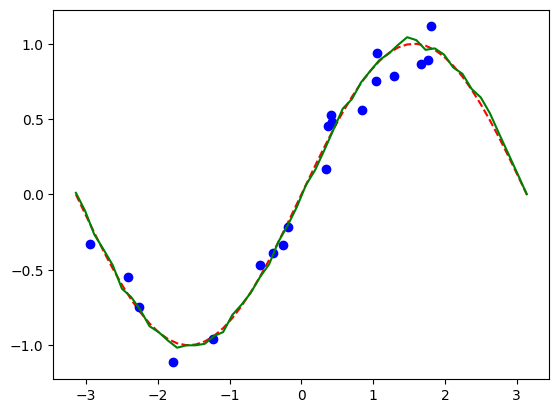

In [6]:
##################################################################################################
# Set up a circuit
param_x = Parameter("x")
feature_map = QuantumCircuit(1, name = "fm")
feature_map.ry(param_x, 0)

param_y = Parameter("y")
ansatz = QuantumCircuit(1, name = "vf")
ansatz.ry(param_y, 0)

qc = QuantumCircuit(1)
qc.compose(feature_map, inplace = True)
qc.compose(ansatz, inplace = True)
display(qc.draw(output = "mpl", style = "clifford"))

##################################################################################################
# Set up a primitive
estimator = Exact_estimator()

##################################################################################################
# Set up an EstimatorQNN
qnn3 = EstimatorQNN(
    circuit = qc,
    weight_params = [param_y],
    input_params = [param_x],
    estimator = estimator,
    pass_manager = None,
    input_gradients = False,
)

##################################################################################################
# Integrate the QNN into a PyTorch module
initial_weights = 0.1 * (2 * algorithm_globals.random.random(qnn3.num_weights) - 1)   # randoms in the range [-0.1, 0.1)
model3 = TorchConnector(qnn3, initial_weights = initial_weights)   # if we don't explicitly declare the initial weights they are chosen uniformly at random from [-1, 1]
print(f"Initial weights: {initial_weights}\n")

##################################################################################################
# Define optimizer and loss
optimizer = LBFGS(model3.parameters())
f_loss3 = MSELoss(reduction = "sum")

##################################################################################################
# Train the model: enter training mode, define closure function performing forward and backward passes, update parameters
model3.train()  # set model to training mode

print("Loss:")
def closure():
    optimizer.zero_grad(set_to_none = True)  # initialize/clear gradients
    outputs = model3(Tensor(X))   # forward pass: compute predicitons
    loss = f_loss3(outputs, Tensor(y))  # evaluate loss function
    loss.backward()  # backward pass: compute the gradient of the loss
    print(loss.item())  # print loss
    return loss
optimizer.step(closure)   # update parameters
print()

##################################################################################################
# Plot results
plt.plot(np.linspace(lb, ub), f(np.linspace(lb, ub)), "r--")   # plot target function
plt.plot(X, y, "bo")   # plot data

model3.eval()
y_ = []
for x in np.linspace(lb, ub):
    output = model3(Tensor([x]))
    y_.append([output.detach().numpy()[0]])
plt.plot(np.linspace(lb, ub), y_, "g-")
plt.show()

# MNIST Classification, Hybrid QNNs

Here we show how to leverage a hybrid quantum-classical neural network using TorchConnector, to perform a more complex image classification task on the MNIST handwritten digits dataset.

**Datapoints:**
datapoints are hand-written images of the 10 digits from 0 to 9.

**Features:**
each pixel is a feature, whose value represent the grey intensity of that pixel (0 = black, 1 = white). The original images have 28 x 28 pixels --> 784 features.

**Classes:**
classes are the 10 digits (from 0 to 9) which is possible to recognize. The original dataset has images of all the 10 digits, but we work only with images of digits 0 and 1 --> 2 classes.

## Step 1: Data loading and pre-processing

Here we extract a subset of images from the MNIST dataset, divide them in a train and a test datasets, and organize them in batches using a DataLoader. The resulting datapoints are PyTorch tensors, one for each batch. Each tensor has rank 4 and the following dimensions: ```batch_size``` x ```num_channels``` x ```image_height``` x ```image_width```. Here we set ```batch_size = 1```, there is only 1 channel (grayscale images), and images are 28 x 28 pixels. We finally plot some datapoints (batches) of the train dataset as a sanity check

### Extracting a train dataset

In [7]:
##################################################################################################
# Set shuffle seed, batch size, and the number of images to include in the train dataset  for each class
manual_seed(42)   # set train shuffle seed for reproducibility
batch_size = 1
n_samples = 100  # take only the first 100 images for each digit

##################################################################################################
# Download train part of the dataset
X_train = datasets.MNIST(
    root = "./data",   # create a "./data" folder to save files in
    train = True,   # download train images only, avoiding test ones
    download = True,   # download images from official servers if they are not already present on the PC
    transform = transforms.Compose([transforms.ToTensor()])   # transform images into PyTorch tensors
)

##################################################################################################
# Filter out labels (originally 0-9), leaving only 0 and 1-labelled images 
idx = np.append(
    np.where(X_train.targets == 0)[0][:n_samples], np.where(X_train.targets == 1)[0][:n_samples]
)   # extract the indexes of the first n_samples images whose class is 0, does the same for class 1, and append the indexes together
X_train.data = X_train.data[idx]   # overwrite the feature part of the original train dataset
X_train.targets = X_train.targets[idx]   # overwrite the label part of the original train dataset

##################################################################################################
# Define a torch dataloader with the filtered dataset
train_loader = DataLoader(X_train, batch_size = batch_size, shuffle = True)   # notice that images are in PyTorch tensor format

### Extracting a test dataset

In [8]:
##################################################################################################
# Set shuffle seed, batch size, and the number of images to include in the test dataset for each class
batch_size = 1
n_samples = 50  # take only the first 100 images for each digit

##################################################################################################
# Download train part of the dataset
X_test = datasets.MNIST(
    root = "./data",   # create a "./data" folder to save files in
    train = False,   # download test images only, avoiding train ones
    download = True,   # download images from official servers if they are not already present on the PC
    transform = transforms.Compose([transforms.ToTensor()])   # transform images into PyTorch tensors
)

##################################################################################################
# Filter out labels (originally 0-9), leaving only 0 and 1-labelled images 
idx = np.append(
    np.where(X_test.targets == 0)[0][:n_samples], np.where(X_test.targets == 1)[0][:n_samples]
)   # extract the indexes of the first n_samples images whose class is 0, does the same for class 1, and append the indexes together
X_test.data = X_test.data[idx]   # overwrite the feature part of the original train dataset
X_test.targets = X_test.targets[idx]   # overwrite the label part of the original train dataset

##################################################################################################
# Define a torch dataloader with the filtered dataset
test_loader = DataLoader(X_test, batch_size = batch_size, shuffle = True)   # notice that images are in PyTorch tensor format

### Train dataloader exploration and visualization - sanity check

The DataLoader object has the following structure:
- dataloader - type: DataLoader; lenght: 200 (the number of bathces)
  - batch - type: list; lenght: 2
    - datapoints/images tensor - type: torch.Tensor; rank: 4; dimension: here 1 x 1 x 28 x 28
      - number of datapoints in the batch (```batch_size```) (here 1)
      - number of color channels (here 1: scale of grays)
      - height of the datapoints in pixel (here 28)
      - width of the datapoints in pixel (here 28)
    - labels of the datapoints in the batch - type: torch.Tensor; rank: 1; dimension: ```batch_size```

Here we show the datapoints/images contained in the first 6 batches of the train dataloader as a check step. Since we set ```batch_size = 1```, each batch contains only 1 image. To perform this sanity check, we create an iterator object pointing at the dataloader elements with ```iter(train_loader)```. We then use the ```next()``` function on the iterator to shift it forward by 1 position and to extract the element it points at (a 2-dimensional list) inside a ```while``` loop. Following the structure above, we plot the image contained in the related batch 

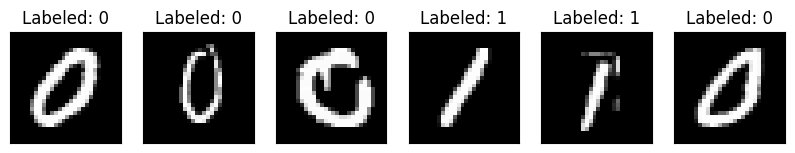

In [9]:
n_samples_show = 6

data_iter = iter(train_loader)   # create an iterator object pointing at positions in the dataloader
fig, axes = plt.subplots(nrows = 1, ncols = n_samples_show, figsize = (10, 3))

while n_samples_show > 0:
    images, targets = next(data_iter)   # move the iterator forward by 1 (initially from pre-start to 0) and extract data from the position it is pointing at

    # extract the first image of the first (and only) color channel (images[0,0]), transforms it into a numpy, and eliminate eventual useless 1-dim dimensions (squeeze)
    axes[n_samples_show - 1].imshow(images[0, 0].numpy().squeeze(), cmap = "gray")   # images[0,0] is a rank-2 tensor of dimension 28 x 28
    axes[n_samples_show - 1].set_xticks([])
    axes[n_samples_show - 1].set_yticks([])
    axes[n_samples_show - 1].set_title("Labeled: {}".format(targets[0].item()))

    n_samples_show -= 1

## Step 2: Defining the QNN and Hybrid Model

### Quantum NN construction

Here we define a quantum neural network layer (in this case, a 2-qubit EstimatorQNN computing the expectation value of $Z_0 \otimes Z_1$) and embed it into a layer in a torch Module by initializing a torch connector as TorchConnector(qnn).

**Attention:** in order to have an adequate gradient backpropagation in hybrid models, we MUST set the initial parameter ```input_gradients``` to TRUE during the qnn initialization.

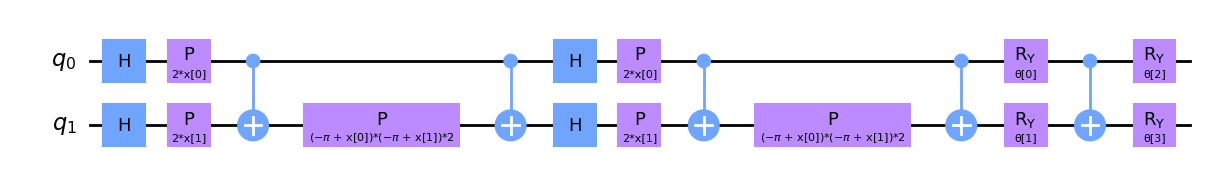

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


In [10]:
##################################################################################################
# Set up a circuit
feature_map = zz_feature_map(2)
ansatz = real_amplitudes(2, reps = 1)
qc = QuantumCircuit(2)
qc.compose(feature_map, inplace = True)
qc.compose(ansatz, inplace = True)
display(qc.draw(output = "mpl", style = "clifford"))

##################################################################################################
# Set up a primitive
estimator = Exact_estimator()

##################################################################################################
# Set up an EstimatorQNN
qnn4 = EstimatorQNN(
    circuit = qc,
    weight_params = ansatz.parameters,
    input_params = feature_map.parameters,
    estimator = estimator,
    pass_manager = None,
    input_gradients = True,   # to enable hybrid gradient backpropagation
)

### Hybrid NN construction: classical part and quantum integration

We now define the Neural Network model as a new class object which inherits from the ```Module``` class.

**Structure:**

0. Inputs are the rank-4 batch tensors with dimension (```batch_size```, ```num_channels```, ```image_height```, ```image_width```), containing the 28 x 28 images. We recall that here ```batch_size = 1``` and ```num_channels = 1``` (grayscale images)
1. convolutional layer #1: looks for 2 patterns (produces 2 output channels) in the original image using a 5 x 5 filter window --> returns 24 x 24 images
2. ReLU #1: nonlinear activation function
3. max_pool2d #1: uses a 2 x 2 filter window (keeps only the most relevant feature in each 2 x 2 pixel grid) --> returns 12 x 12 images
4. convolutional layer #2: takes 2 input channels and looks for 16 patterns (produces 16 output channels) using a 5 x 5 filter window --> returns 8 x 8 images
5. max_pool2d #2: uses a 2 x 2 filter window --> returns 4 x 4 images
6. dropout function: turns off part of the neurons to avoid overfitting
7. data reshape: takes 16 channels of 4 x 4 images and flattens them in a 256-dimensional array (256 = 16 x 4 x 4)
8. linear layer #1: from 256 neurons to 64
9. ReLU #2: nonlinear activation function
10. linear layer #2: from 64 neurons to 2
11. **Quantum NN integration**: takes 2 input parameters and return 1 output (the measured expectation value of $Z_0 \otimes Z_1$)
12. linear layer #3: from 1 neuron to 1. Takes the single QNN output and returns a rank-2 PyTorch tensor of dimensions  (1 x 1)
13. output mapping: concatenate the output tensor ```x``` with the tensor ```1-x``` to crate a single PyTorch tensor as output, along the last available dimension. Returns a rank 2 PyTorch tensor of dimension (```batch_size```, 2) (here (1, 2): [[class_0_probability, class_1_probability]])

In [11]:
##################################################################################################
# Define torch NN module
class Net(Module):   # define a class named Net which inherits from PyTorch's Module class
    def __init__(self, qnn):   # define the initialization method automatically executed when creating a Net() object. Takes one parameter (qnn)
        super().__init__()   # retrieve the parent class of Net, i.e., Module, and apply its initialization method to the class which is being built
        self.conv1 = Conv2d(1, 2, kernel_size = 5)   # convolutional layer 
        self.conv2 = Conv2d(2, 16, kernel_size = 5)
        self.dropout = Dropout2d()   # convolutional layer
        self.fc1 = Linear(256, 64)   # linear layer
        self.fc2 = Linear(64, 2) 
        self.qnn = TorchConnector(qnn)  # QNN integration. Weights chosen uniformly at random from interval [-1,1]
        self.fc3 = Linear(1, 1)  # 1-dimensional output from QNN

    def forward(self, x):   # define the method for forward propagation. Takes one parameter x (the batch tensors)
        x = F.relu(self.conv1(x))   # input: (1, 1, 28, 28) -> output: (1, 2, 24, 24)
        x = F.max_pool2d(x, 2)   # output: (1, 2, 12, 12)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = self.dropout(x)
        x = x.view(x.shape[0], -1)   # reshaping function. Output: (1, 256)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        x = self.qnn(x)
        x = self.fc3(x)
        return cat((x, 1 - x), -1)   # output mapping

model4 = Net(qnn4)   # initialize the model

## Step 3: Training

Training [5%]	Loss: -1.1349
Training [10%]	Loss: -1.5433
Training [15%]	Loss: -1.7681
Training [20%]	Loss: -2.0290
Training [25%]	Loss: -2.2569
Training [30%]	Loss: -2.4413
Training [35%]	Loss: -2.6448
Training [40%]	Loss: -2.8504
Training [45%]	Loss: -3.0748
Training [50%]	Loss: -3.2740
Training [55%]	Loss: -3.4985
Training [60%]	Loss: -3.7121
Training [65%]	Loss: -3.9336
Training [70%]	Loss: -4.1051
Training [75%]	Loss: -4.3320
Training [80%]	Loss: -4.5365
Training [85%]	Loss: -4.7374
Training [90%]	Loss: -4.9215
Training [95%]	Loss: -5.0970
Training [100%]	Loss: -5.3146


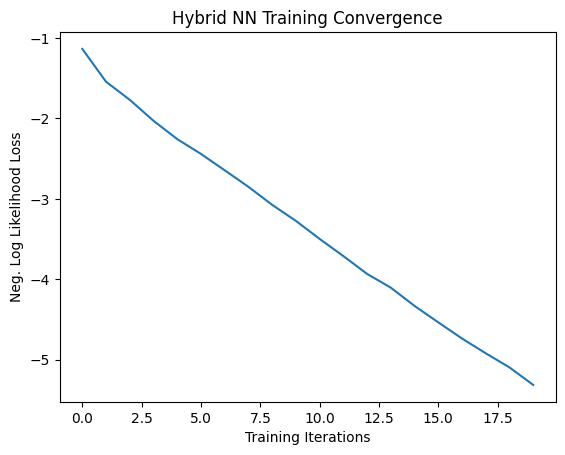

In [12]:
##################################################################################################
# Define model, optimizer, and loss function
optimizer = optim.Adam(model4.parameters(), lr = 0.001)
loss_func = NLLLoss()

##################################################################################################
# Start training
epochs = 20  # set number of epochs
loss_list = []  # store loss history
model4.train()  # set model to training mode

for epoch in range(epochs):
    total_loss = []
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad(set_to_none = True)  # initialize gradient
        output = model4(data)  # forward pass
        loss = loss_func(output, target)  # calculate loss
        loss.backward()  # backward pass
        optimizer.step()  # optimize weights
        total_loss.append(loss.item())  # store loss
    loss_list.append(sum(total_loss) / len(total_loss))
    print("Training [{:.0f}%]\tLoss: {:.4f}".format(100.0 * (epoch + 1) / epochs, loss_list[-1]))

##################################################################################################
# Plot loss convergence
plt.plot(loss_list)
plt.title("Hybrid NN Training Convergence")
plt.xlabel("Training Iterations")
plt.ylabel("Neg. Log Likelihood Loss")
plt.show()

In [13]:
##################################################################################################
# Save the trained PyTorch model for later retrieve
torch.save(model4.state_dict(), "model4.pt")   # only save the dictionary of current weights and biases, not the whole model

## Step 4: Evaluation

We now create a new QNN layer identical to the previous one, and use it to create a new empty ```Net``` neural network object. We then load the previously saved model (weights and biases only) and inject it the new empty NN. After loading, the model must be set to evaluation mode. Finally, we evaluate the model performance

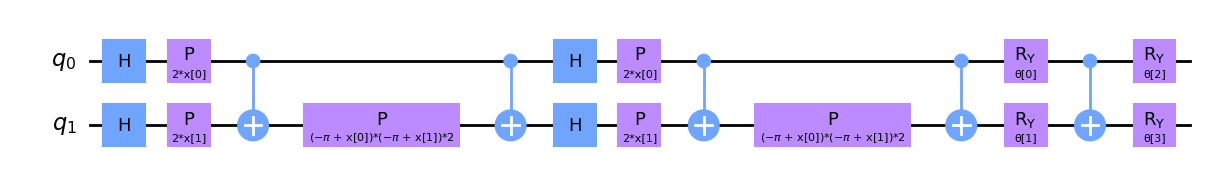

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


<All keys matched successfully>

In [14]:
##################################################################################################
# Set up a circuit
feature_map = zz_feature_map(2)
ansatz = real_amplitudes(2, reps = 1)
qc = QuantumCircuit(2)
qc.compose(feature_map, inplace = True)
qc.compose(ansatz, inplace = True)
display(qc.draw(output = "mpl", style = "clifford"))

##################################################################################################
# Set up a primitive
estimator = Exact_estimator()

##################################################################################################
# Set up an EstimatorQNN
qnn5 = EstimatorQNN(
    circuit = qc,
    weight_params = ansatz.parameters,
    input_params = feature_map.parameters,
    estimator = estimator,
    pass_manager = None,
    input_gradients = True,   # to enable hybrid gradient backpropagation
)

##################################################################################################
# Create a new NN model using the Net class and feed it with loaded weights and biases from previous training
model5 = Net(qnn5)
model5.load_state_dict(torch.load("model4.pt"))

Performance on test data:
	Loss: -5.3732
	Accuracy: 100.0%


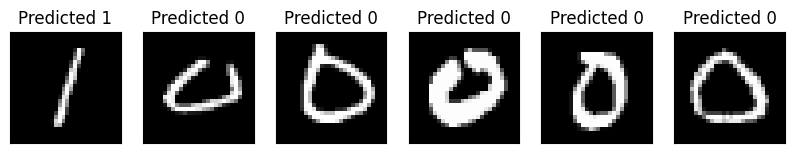

In [16]:
##################################################################################################
# Evaluate model
model5.eval()  # set model to evaluation mode
with no_grad():
    correct = 0
    for data, target in test_loader:
        output = model5(data)
        if len(output.shape) == 1:
            output = output.reshape(1, *output.shape)

        pred = output.argmax(dim = 1, keepdim = True)
        correct += pred.eq(target.view_as(pred)).sum().item()

        loss = loss_func(output, target)
        total_loss.append(loss.item())

    print(
        "Performance on test data:\n\tLoss: {:.4f}\n\tAccuracy: {:.1f}%".format(
            sum(total_loss) / len(total_loss), correct / len(test_loader) / batch_size * 100
        )
    )

##################################################################################################
# Plot predicted labels
n_samples_show = 6
count = 0
fig, axes = plt.subplots(nrows=1, ncols=n_samples_show, figsize=(10, 3))

model5.eval()
with no_grad():
    for batch_idx, (data, target) in enumerate(test_loader):
        if count == n_samples_show:
            break
        output = model5(data[0:1])
        if len(output.shape) == 1:
            output = output.reshape(1, *output.shape)

        pred = output.argmax(dim=1, keepdim=True)

        axes[count].imshow(data[0].numpy().squeeze(), cmap="gray")

        axes[count].set_xticks([])
        axes[count].set_yticks([])
        axes[count].set_title("Predicted {}".format(pred.item()))

        count += 1

# Copyright

This code is a part of a Qiskit project
© Copyright IBM 2017, 2025.

This code is licensed under the Apache License, Version 2.0. You may
obtain a copy of this license in the LICENSE.txt file in the root directory
of this source tree or at http://www.apache.org/licenses/LICENSE-2.0.